# **📊 Dataset Quality Assessment**

## Technical Assessment Report

**Candidate:** Sumaira Ashiq

**Task:** Data Audit Report

**Dataset:** defect_annotations.csv

---


### **Load the Dataset**

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df = pd.read_csv("defect_annotations.csv")

# Display first 5 rows
df.head()

,filename,polygon_xy,class
0,img_0148.png,121.1 742.5 110.4 745.9 99.1 746.5 91.4 737.4 ...,Bubble
1,img_0118.png,1053.8 720.2 984.5 876.2 980.9 874.6 1050.9 718.9,Scratch
2,img_0062.png,326.7 764.1 374.3 782.2 419.8 805.1 466.9 824....,Scratch
3,img_0091.png,36.5 399.4 36.6 377.4 59.3 359.3 83.7 358.8 91...,Dent
4,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent


### **Dataset Shape**

In [59]:
print("Dataset Shape:", df.shape)

Dataset Shape: (442, 3)


### **Column Names**

In [60]:
print(df.columns)

Index(['filename', 'polygon_xy', 'class'], dtype='object')


### **Dataset Information**

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   filename    442 non-null    object
 1   polygon_xy  441 non-null    object
 2   class       442 non-null    object
dtypes: object(3)
memory usage: 10.5+ KB


### **Missing Values Check**

In [62]:
print(df.isnull().sum())

filename      0
polygon_xy    1
class         0
dtype: int64


### **Missing Values per Column**

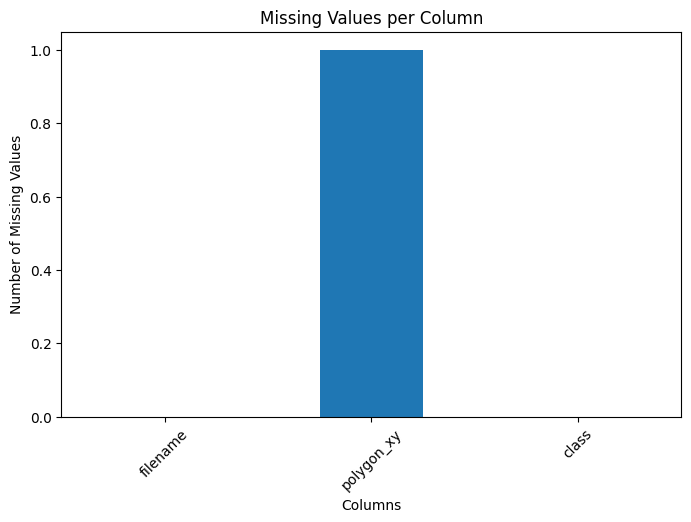

In [63]:

# Missing values
missing = df.isnull().sum()

# Plot
plt.figure(figsize=(8,5))
missing.plot(kind='bar')

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.show()

### **Unique Classes in Dataset**

In [64]:
print("Unique Classes:")
print(df["class"].unique())

Unique Classes:
['Bubble' 'Scratch' 'Dent' 'Crack' 'bubble' 'Scratches' 'scratch']


### **Class Distribution**

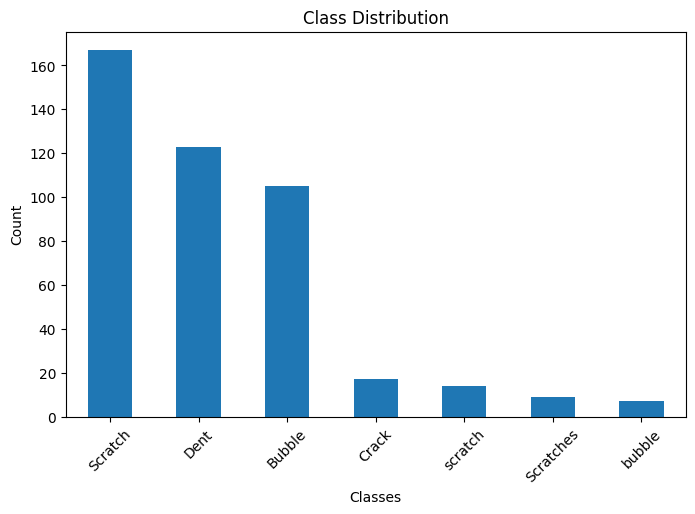

In [65]:


# Count classes
class_counts = df["class"].value_counts()

# Plot
plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.show()

### **Class Frequency Count**

In [66]:
print(df["class"].value_counts())

class
Scratch      167
Dent         123
Bubble       105
Crack         17
scratch       14
Scratches      9
bubble         7
Name: count, dtype: int64


### **Duplicate Records Check**

In [67]:
duplicates = df.duplicated().sum()

print("Total Duplicate Records:", duplicates)

Total Duplicate Records: 15


### **View Duplicate Records**

In [68]:
duplicate_rows = df[df.duplicated()]

duplicate_rows

,filename,polygon_xy,class
10,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent
96,img_0141.png,1145.6 472.8 1140.5 454.4 1153.0 435.9 1170.9 ...,Dent
208,img_0029.png,98.1 433.4 94.8 418.0 99.3 403.5 113.8 397.6 1...,Bubble
228,img_0124.png,1037.5 345.6 1042.3 327.4 1059.6 320.6 1079.1 ...,Bubble
240,img_0066.png,819.2 789.3 804.1 786.9 792.9 776.9 792.4 761....,Bubble
282,img_0076.png,526.5 331.0 534.5 298.9 566.2 272.8 607.6 270....,Dent
284,img_0134.png,741.4 214.9 735.8 224.6 723.1 224.4 714.8 216....,Bubble
287,img_0073.png,342.5 746.1 368.1 770.7 400.8 783.6 427.7 806....,Crack
328,img_0128.png,1041.8 802.0 1082.0 856.1 1077.4 859.2 1040.5 ...,Scratch
367,img_0092.png,963.7 332.6 929.7 342.2 895.0 349.2 860.9 358....,Scratch


### **Missing Values in Polygon Column**

In [69]:
df["polygon_xy"].isna().sum()

np.int64(1)

### **Polygon Coordinate Analysis**

In [70]:
def count_coordinates(polygon):
    if pd.isna(polygon):
        return 0
    numbers = str(polygon).split()
    return len(numbers)

df["coordinate_count"] = df["polygon_xy"].apply(count_coordinates)

df[["polygon_xy", "coordinate_count"]].head()

,polygon_xy,coordinate_count
0,121.1 742.5 110.4 745.9 99.1 746.5 91.4 737.4 ...,18
1,1053.8 720.2 984.5 876.2 980.9 874.6 1050.9 718.9,8
2,326.7 764.1 374.3 782.2 419.8 805.1 466.9 824....,16
3,36.5 399.4 36.6 377.4 59.3 359.3 83.7 358.8 91...,14
4,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,14


### **Missing Polygon Records**

In [71]:
df[df["polygon_xy"].isna()]

,filename,polygon_xy,class,coordinate_count
189,img_0074.png,NaN,Bubble,0


### **Feature Engineering: Coordinate Count**

In [72]:
def count_coordinates(polygon):
    if pd.isna(polygon):
        return 0
    numbers = str(polygon).split()
    return len(numbers)

df["coordinate_count"] = df["polygon_xy"].apply(count_coordinates)

df[["polygon_xy", "coordinate_count"]].head()

,polygon_xy,coordinate_count
0,121.1 742.5 110.4 745.9 99.1 746.5 91.4 737.4 ...,18
1,1053.8 720.2 984.5 876.2 980.9 874.6 1050.9 718.9,8
2,326.7 764.1 374.3 782.2 419.8 805.1 466.9 824....,16
3,36.5 399.4 36.6 377.4 59.3 359.3 83.7 358.8 91...,14
4,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,14


### **Valid Coordinate Pair Check**

In [73]:
# Check whether coordinate count is even

df["valid_coordinate_pairs"] = df["coordinate_count"] % 2 == 0

print(df["valid_coordinate_pairs"].value_counts())

valid_coordinate_pairs
True    442
Name: count, dtype: int64


### **Invalid Coordinate Records**

In [74]:
invalid_pairs = df[df["valid_coordinate_pairs"] == False]

invalid_pairs[["filename", "polygon_xy", "coordinate_count"]]

,filename,polygon_xy,coordinate_count


### **Polygon Point Count Calculation**

In [75]:
# Calculate number of polygon points

df["point_count"] = df["coordinate_count"] // 2

df[["filename", "coordinate_count", "point_count"]].head()

,filename,coordinate_count,point_count
0,img_0148.png,18,9
1,img_0118.png,8,4
2,img_0062.png,16,8
3,img_0091.png,14,7
4,img_0137.png,14,7


### **Invalid Polygon Detection**

In [76]:
invalid_polygons = df[df["point_count"] < 3]

print("Invalid polygons:", len(invalid_polygons))

invalid_polygons[
    ["filename", "polygon_xy", "point_count", "class"]
]

Invalid polygons: 4


,filename,polygon_xy,point_count,class
7,img_0023.png,700.0 500.0,1,Bubble
110,img_0011.png,300.0 220.0 360.0 240.0,2,Crack
189,img_0074.png,NaN,0,Bubble
286,img_0005.png,120.0 140.0 180.0 150.0,2,Scratch


### **Duplicate Rows Summary**

In [77]:
duplicate_rows = df[df.duplicated()]

print("Duplicate rows:", len(duplicate_rows))

Duplicate rows: 15


### **View Duplicate Rows**

In [78]:
duplicate_rows

,filename,polygon_xy,class,coordinate_count,valid_coordinate_pairs,point_count
10,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent,14,True,7
96,img_0141.png,1145.6 472.8 1140.5 454.4 1153.0 435.9 1170.9 ...,Dent,16,True,8
208,img_0029.png,98.1 433.4 94.8 418.0 99.3 403.5 113.8 397.6 1...,Bubble,16,True,8
228,img_0124.png,1037.5 345.6 1042.3 327.4 1059.6 320.6 1079.1 ...,Bubble,14,True,7
240,img_0066.png,819.2 789.3 804.1 786.9 792.9 776.9 792.4 761....,Bubble,16,True,8
282,img_0076.png,526.5 331.0 534.5 298.9 566.2 272.8 607.6 270....,Dent,16,True,8
284,img_0134.png,741.4 214.9 735.8 224.6 723.1 224.4 714.8 216....,Bubble,16,True,8
287,img_0073.png,342.5 746.1 368.1 770.7 400.8 783.6 427.7 806....,Crack,16,True,8
328,img_0128.png,1041.8 802.0 1082.0 856.1 1077.4 859.2 1040.5 ...,Scratch,8,True,4
367,img_0092.png,963.7 332.6 929.7 342.2 895.0 349.2 860.9 358....,Scratch,16,True,8


### **Duplicate Records (Based on Key Columns)**

In [79]:
duplicates = df[
    df.duplicated(
        subset=["filename", "polygon_xy", "class"],
        keep=False
    )
]

duplicates

,filename,polygon_xy,class,coordinate_count,valid_coordinate_pairs,point_count
4,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent,14,True,7
6,img_0141.png,1145.6 472.8 1140.5 454.4 1153.0 435.9 1170.9 ...,Dent,16,True,8
10,img_0137.png,227.2 160.4 206.1 157.2 194.0 125.9 199.9 98.2...,Dent,14,True,7
24,img_0073.png,342.5 746.1 368.1 770.7 400.8 783.6 427.7 806....,Crack,16,True,8
33,img_0128.png,1041.8 802.0 1082.0 856.1 1077.4 859.2 1040.5 ...,Scratch,8,True,4
65,img_0029.png,98.1 433.4 94.8 418.0 99.3 403.5 113.8 397.6 1...,Bubble,16,True,8
66,img_0112.png,85.4 897.4 99.1 926.5 114.4 954.8 111.0 956.7 ...,Scratch,12,True,6
81,img_0124.png,1037.5 345.6 1042.3 327.4 1059.6 320.6 1079.1 ...,Bubble,14,True,7
82,img_0066.png,819.2 789.3 804.1 786.9 792.9 776.9 792.4 761....,Bubble,16,True,8
96,img_0141.png,1145.6 472.8 1140.5 454.4 1153.0 435.9 1170.9 ...,Dent,16,True,8


### **Unique Classes in Dataset**

In [80]:
print(df["class"].unique())

['Bubble' 'Scratch' 'Dent' 'Crack' 'bubble' 'Scratches' 'scratch']


### **Define Valid Classes**

In [81]:
valid_classes = ["Scratch", "Crack", "Bubble", "Dent"]

### **Invalid Class Labels Detection**

In [82]:
invalid_classes = df[~df["class"].isin(valid_classes)]

print("Invalid class labels:", len(invalid_classes))

invalid_classes[["filename", "class"]]

Invalid class labels: 30


,filename,class
27,img_0121.png,bubble
94,img_0080.png,Scratches
99,img_0087.png,scratch
109,img_0115.png,scratch
123,img_0129.png,scratch
128,img_0077.png,scratch
172,img_0067.png,scratch
182,img_0053.png,Scratches
195,img_0098.png,scratch
198,img_0014.png,scratch


### **Class Distribution Visualization**

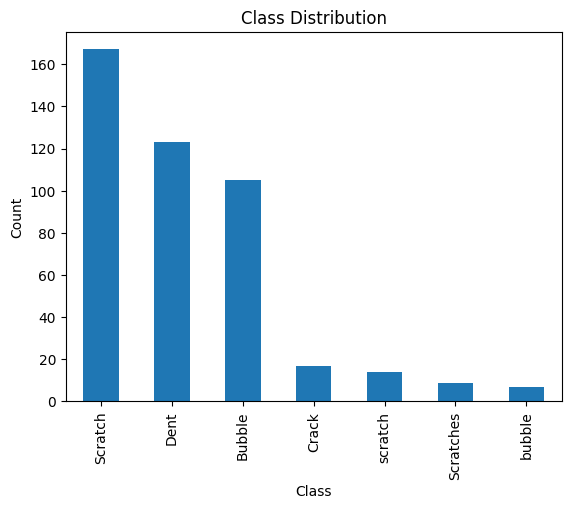

In [83]:
import matplotlib.pyplot as plt

df["class"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

### **Out-of-Bounds Polygon Detection**

In [84]:
def check_out_of_bounds(polygon):
    if pd.isna(polygon):
        return True

    numbers = list(map(float, str(polygon).split()))

    for i in range(0, len(numbers), 2):
        x = numbers[i]
        y = numbers[i + 1]

        if x < 0 or x > 1280 or y < 0 or y > 1024:
            return True

    return False

### **Out-of-Bounds Feature Creation**

In [85]:
df["out_of_bounds"] = df["polygon_xy"].apply(check_out_of_bounds)

### **Out-of-Bounds Summary**

In [86]:
print(df["out_of_bounds"].value_counts())

out_of_bounds
False    438
True       4
Name: count, dtype: int64


### **Out-of-Bounds Records Inspection**

In [87]:
df[df["out_of_bounds"]][
    ["filename", "polygon_xy", "class"]
]

,filename,polygon_xy,class
49,img_0031.png,-25.0 300.0 60.0 305.0 50.0 360.0 -30.0 355.0,Dent
129,img_0091.png,500.0 -10.0 560.0 -15.0 555.0 40.0 495.0 45.0,Bubble
189,img_0074.png,NaN,Bubble
202,img_0047.png,1100.0 980.0 1340.0 990.0 1330.0 1090.0 1095.0...,Dent


### **Class Distribution Count**

In [88]:
class_counts = df["class"].value_counts()

print(class_counts)

class
Scratch      167
Dent         123
Bubble       105
Crack         17
scratch       14
Scratches      9
bubble         7
Name: count, dtype: int64


### **Final Visualization: Class Distribution**

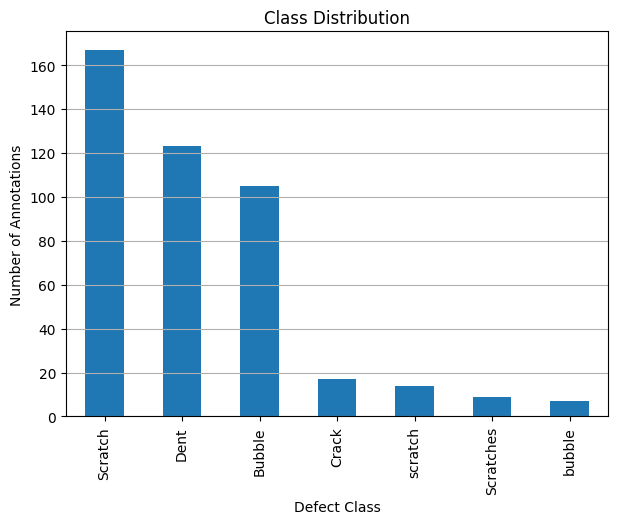

In [89]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Defect Class")
plt.ylabel("Number of Annotations")

plt.grid(axis="y")

plt.show()

### **Class Distribution (Percentage View)**

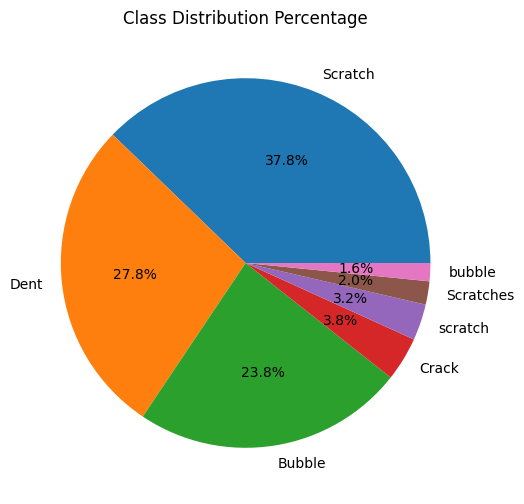

In [90]:
plt.figure(figsize=(6,6))

class_counts.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")

plt.title("Class Distribution Percentage")

plt.show()

### **Bounding Box Feature Extraction**

In [91]:
def bounding_box_size(polygon):
    if pd.isna(polygon):
        return pd.Series([0, 0])

    nums = list(map(float, str(polygon).split()))

    xs = nums[0::2]
    ys = nums[1::2]

    width = max(xs) - min(xs)
    height = max(ys) - min(ys)

    return pd.Series([width, height])

df[["bbox_width", "bbox_height"]] = df["polygon_xy"].apply(bounding_box_size)

### **Bounding Box Features Preview**

In [92]:
df[["filename","bbox_width","bbox_height"]].head()

,filename,bbox_width,bbox_height
0,img_0148.png,30.2,31.5
1,img_0118.png,72.9,157.3
2,img_0062.png,141.3,62.0
3,img_0091.png,55.3,48.3
4,img_0137.png,49.4,72.2


### **Bounding Box Width Distribution**

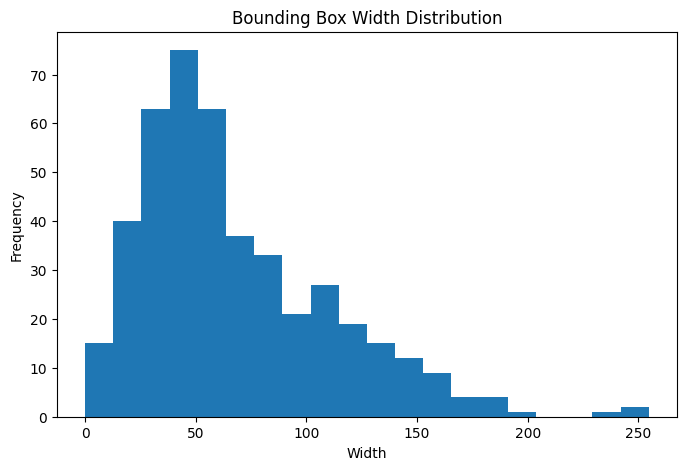

In [93]:
plt.figure(figsize=(8,5))

plt.hist(df["bbox_width"], bins=20)

plt.title("Bounding Box Width Distribution")
plt.xlabel("Width")
plt.ylabel("Frequency")

plt.show()

### **Bounding Box Height Distribution**

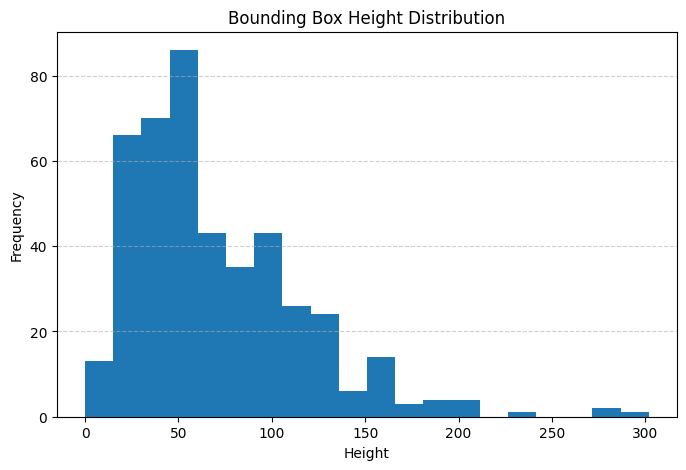

In [95]:
plt.figure(figsize=(8,5))
plt.hist(df["bbox_height"], bins=20)
plt.title("Bounding Box Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()